# Topic 20: Multiple Testing & False Discovery

Notebook companion to `src/content/topics/multiple-testing-and-false-discovery.mdx`.
Produces all 9 static figures for the topic and emits the test-harness values
consumed by `src/lib/stat/testing.ts`'s regression tests.

**Figures produced** (all saved to `public/images/topics/multiple-testing-and-false-discovery/`):

1. `20-fwer-explosion.png` — motivation (§20.1)
2. `20-closed-testing-tree.png` — closed-testing principle (§20.2)
3. `20-pvalue-mixture.png` — null/alt p-value mixture (§20.3)
4. `20-bonferroni-vs-holm.png` — FWER step-down (§20.5)
5. `20-bh-algorithm.png` — BH procedure (§20.7)
6. `20-fdr-fwer-power.png` — 3-row comparison across π₀ (§20.8)
7. `20-genomics-simulation.png` — m=20K realistic scale (§20.8)
8. `20-simultaneous-cis.png` — Bonferroni-adjusted joint coverage (§20.9)
9. `20-forward-map.png` — Track 5 close, forward to Tracks 6/8 and formalml.com (§20.10)

**Seed** = 42 throughout. Figures re-seed locally where sampling occurs so each
figure is reproducible in isolation. Continues the Topic 17–19 palette, extended
with a purple-family for FWER procedures and a green-family for FDR procedures.


In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports + seed (reuse Topic 19's setup, extended)
# ═══════════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
from matplotlib.patches import FancyArrowPatch

SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "public/images/topics/multiple-testing-and-false-discovery"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")
print(f"Seed: {SEED}")

Output directory: public/images/topics/multiple-testing-and-false-discovery
Seed: 42


In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Palette + matplotlib defaults + procedure helpers
# ═══════════════════════════════════════════════════════════════════════════════

# Track 5 palette (inherited from Topic 19), extended for Topic 20.
C = {
    # Inherited from Topics 17–19
    'wald':   '#D97706',   # amber     — Wald
    'score':  '#7C3AED',   # purple    — Score / Wilson
    'lrt':    '#10B981',   # green     — LRT (reused as BH)
    'ref':    '#475569',   # grey      — reference / theoretical
    'pivot':  '#2563EB',   # blue      — pivot / CI framework
    'warn':   '#DC2626',   # red       — warning / miscoverage

    # Topic 20 additions — FWER family (purples, darkest = most conservative)
    'bonf':   '#6B21A8',   # purple-800 — Bonferroni (single-step)
    'holm':   '#9333EA',   # purple-600 — Holm (step-down)
    'sidak':  '#A855F7',   # purple-500 — Šidák (single-step, indep.)
    'hoch':   '#C084FC',   # purple-400 — Hochberg (step-up)

    # Topic 20 additions — FDR family (greens)
    'bh':     '#10B981',   # emerald-500 — BH (same hex as 'lrt' by design)
    'by':     '#047857',   # emerald-700 — Benjamini-Yekutieli
    'storey': '#34D399',   # emerald-400 — Storey adaptive q-value

    # Mixture coloring
    'null':   '#94A3B8',   # slate      — p-values under H0
    'alt':    '#F59E0B',   # amber      — p-values under H1
}

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.axisbelow': True,
})

# ─── Procedure helpers (reused across figures; match testing.ts API) ─────────

def bonferroni(pvals, alpha=0.05):
    """Single-step FWER. Reject H_i iff p_i < alpha / m."""
    m = len(pvals)
    return pvals < (alpha / m)

def holm(pvals, alpha=0.05):
    """Step-down FWER (Holm 1979). Sort ascending; stop at first failure."""
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    reject_sorted = np.zeros(m, dtype=bool)
    for i in range(m):
        if sorted_p[i] < alpha / (m - i):
            reject_sorted[i] = True
        else:
            break
    reject = np.zeros(m, dtype=bool)
    reject[order] = reject_sorted
    return reject

def sidak(pvals, alpha=0.05):
    """Šidák FWER under independence: p_i < 1 - (1-alpha)^(1/m)."""
    m = len(pvals)
    return pvals < 1 - (1 - alpha) ** (1 / m)

def hochberg(pvals, alpha=0.05):
    """Step-up FWER (Hochberg 1988). Valid under independence."""
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    reject_sorted = np.zeros(m, dtype=bool)
    for k in range(m, 0, -1):
        if sorted_p[k-1] <= alpha / (m - k + 1):
            reject_sorted[:k] = True
            break
    reject = np.zeros(m, dtype=bool)
    reject[order] = reject_sorted
    return reject

def bh(pvals, alpha=0.05):
    """Benjamini–Hochberg FDR (1995). Step-up. Find largest k with p_(k) <= k*alpha/m."""
    m = len(pvals)
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    reject_sorted = np.zeros(m, dtype=bool)
    for k in range(m, 0, -1):
        if sorted_p[k-1] <= k * alpha / m:
            reject_sorted[:k] = True
            break
    reject = np.zeros(m, dtype=bool)
    reject[order] = reject_sorted
    return reject

def by(pvals, alpha=0.05):
    """Benjamini–Yekutieli FDR (2001) — valid under arbitrary dependence."""
    m = len(pvals)
    c_m = np.sum(1.0 / np.arange(1, m + 1))   # harmonic number H_m
    return bh(pvals, alpha=alpha / c_m)

def storey_bh(pvals, alpha=0.05, lam=0.5):
    """Storey (2002) adaptive BH. Estimate pi_0, then apply BH at alpha/pi_0."""
    m = len(pvals)
    pi0_hat = np.mean(pvals >= lam) / (1 - lam)
    pi0_hat = min(pi0_hat, 1.0)
    if pi0_hat == 0:
        return np.ones(m, dtype=bool)
    return bh(pvals, alpha=alpha / pi0_hat)

# ─── MC helper: simulate m p-values from a two-component mixture ──────────────

def simulate_pvalues(m, pi0, signal_strength, rng):
    """Generate m p-values: pi0*m from U(0,1); (1-pi0)*m from one-sided z-test
    with effect size `signal_strength`. Returns (pvals, is_null) shuffled."""
    m0 = int(round(pi0 * m))
    m1 = m - m0
    null_p = rng.uniform(0, 1, size=m0)
    z_alt = rng.normal(signal_strength, 1, size=m1)
    alt_p = 1 - norm.cdf(z_alt)
    pvals = np.concatenate([null_p, alt_p])
    is_null = np.concatenate([np.ones(m0, dtype=bool), np.zeros(m1, dtype=bool)])
    idx = rng.permutation(m)
    return pvals[idx], is_null[idx]

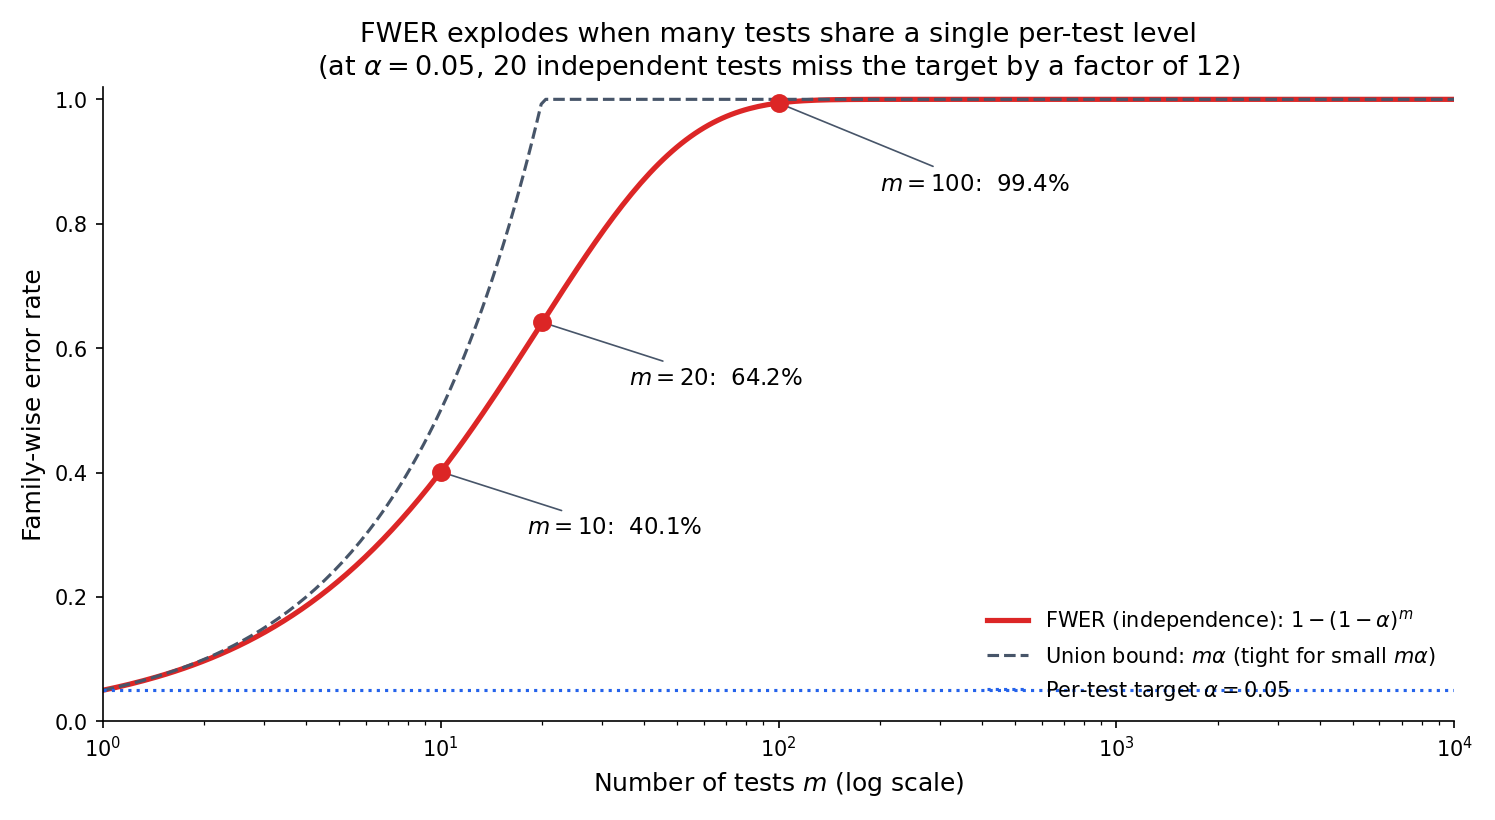

Saved 20-fwer-explosion.png


In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Figure 1: FWER explosion motivation (§20.1)
# Under independence, 1 - (1-alpha)^m explodes rapidly past alpha.
# ═══════════════════════════════════════════════════════════════════════════════

np.random.seed(SEED)

alpha = 0.05
m_grid = np.logspace(0, 4, 300)
fwer_indep = 1 - (1 - alpha) ** m_grid
union_bound = np.minimum(m_grid * alpha, 1.0)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.semilogx(m_grid, fwer_indep, color=C['warn'], lw=2.5,
            label=r'FWER (independence): $1 - (1-\alpha)^m$')
ax.semilogx(m_grid, union_bound, color=C['ref'], lw=1.5, ls='--',
            label=r'Union bound: $m\alpha$ (tight for small $m\alpha$)')
ax.axhline(alpha, color=C['pivot'], lw=1.5, ls=':',
           label=fr'Per-test target $\alpha = {alpha}$')

# Annotate three key m values with exact FWER
for m_target in [10, 20, 100]:
    fwer_val = 1 - (1 - alpha) ** m_target
    ax.scatter([m_target], [fwer_val], color=C['warn'], s=65, zorder=5)
    label = f'$m = {m_target}$:  ' + f'{fwer_val:.1%}'
    dx = 1.8 if m_target < 50 else 2.0
    dy = -0.10 if m_target < 50 else -0.14
    ax.annotate(label, xy=(m_target, fwer_val),
                xytext=(m_target * dx, fwer_val + dy),
                fontsize=11,
                arrowprops=dict(arrowstyle='-', color=C['ref'], lw=0.8))

ax.set_xlabel(r'Number of tests $m$ (log scale)')
ax.set_ylabel('Family-wise error rate')
ax.set_title('FWER explodes when many tests share a single per-test level\n'
             r'(at $\alpha = 0.05$, 20 independent tests miss the target by a factor of 12)')
ax.legend(loc='lower right', frameon=False)
ax.set_ylim(0, 1.02)
ax.set_xlim(1, 1e4)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-fwer-explosion.png'))
plt.show()
print("Saved 20-fwer-explosion.png")

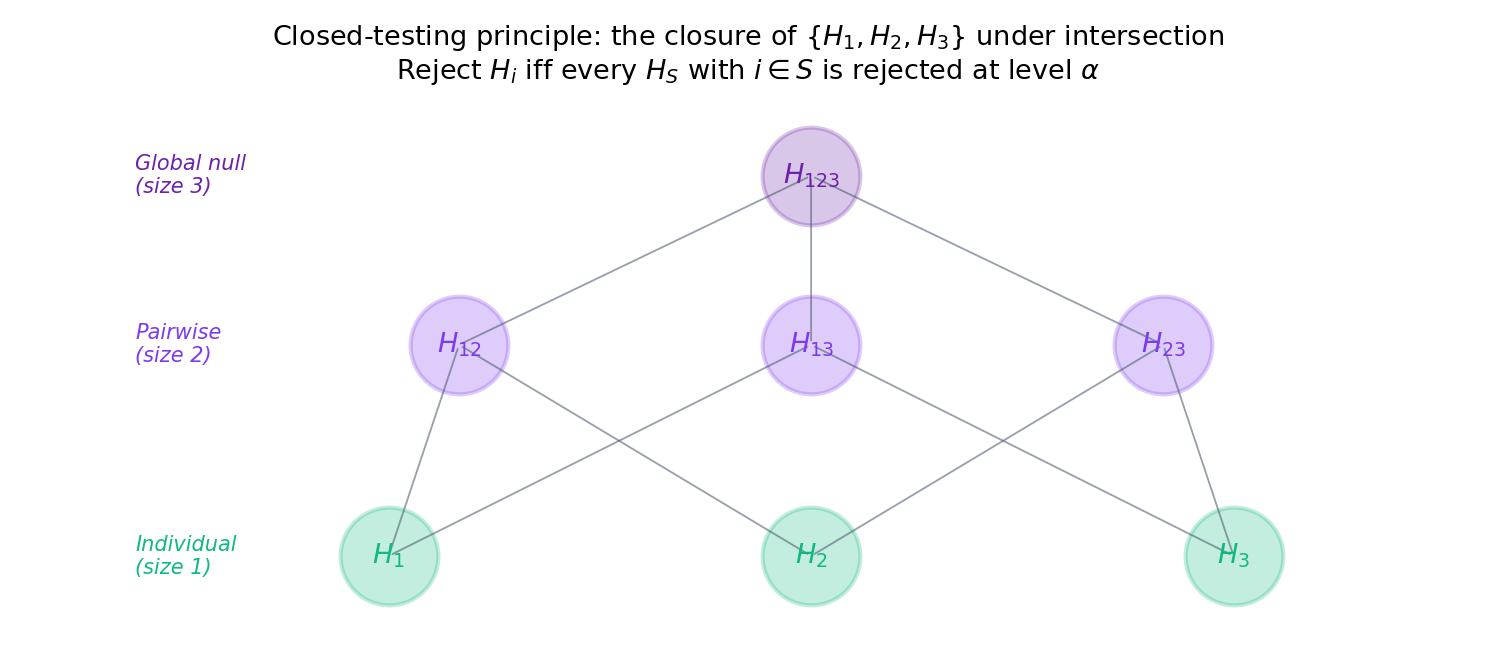

Saved 20-closed-testing-tree.png


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Figure 2: Closed-testing principle tree (§20.2)
# Closure of {H1, H2, H3} under intersection: 7 hypotheses in 3 levels.
# Reject H_i iff every H_S in the closure containing H_i is rejected at level alpha.
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

# Node positions: level 3 (top), level 2 (middle), level 1 (bottom)
positions = {
    'H123': (4.5, 3.0),
    'H12':  (2.0, 1.8), 'H13': (4.5, 1.8), 'H23': (7.0, 1.8),
    'H1':   (1.5, 0.3), 'H2':  (4.5, 0.3), 'H3':  (7.5, 0.3),
}
labels = {
    'H123': r'$H_{123}$',
    'H12':  r'$H_{12}$', 'H13': r'$H_{13}$', 'H23': r'$H_{23}$',
    'H1':   r'$H_{1}$',  'H2':  r'$H_{2}$',  'H3':  r'$H_{3}$',
}

# Color by level (1 = individual, 2 = pairwise, 3 = global)
level_color = {1: C['bh'], 2: C['score'], 3: C['bonf']}

for key, pos in positions.items():
    lev = len(key) - 1
    color = level_color[lev]
    ax.scatter(*pos, s=2200, color=color, alpha=0.25, edgecolor=color, linewidth=2, zorder=3)
    ax.annotate(labels[key], pos, ha='center', va='center', fontsize=13,
                fontweight='bold', color=color, zorder=4)

# Edges: each H_S ⊃ H_i gives an arrow from S to i (closure containment)
edges = [
    ('H123', 'H12'), ('H123', 'H13'), ('H123', 'H23'),
    ('H12', 'H1'),   ('H12', 'H2'),
    ('H13', 'H1'),   ('H13', 'H3'),
    ('H23', 'H2'),   ('H23', 'H3'),
]
for parent, child in edges:
    p = positions[parent]; c = positions[child]
    ax.annotate('', xy=c, xytext=p,
                arrowprops=dict(arrowstyle='-', color=C['ref'], lw=0.9, alpha=0.55))

# Level annotations on the left
ax.text(-0.3, 3.0, 'Global null\n(size 3)', fontsize=10, ha='left', va='center',
        style='italic', color=level_color[3])
ax.text(-0.3, 1.8, 'Pairwise\n(size 2)', fontsize=10, ha='left', va='center',
        style='italic', color=level_color[2])
ax.text(-0.3, 0.3, 'Individual\n(size 1)', fontsize=10, ha='left', va='center',
        style='italic', color=level_color[1])

ax.set_xlim(-1.1, 9.2)
ax.set_ylim(-0.3, 3.6)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Closed-testing principle: the closure of $\\{H_1, H_2, H_3\\}$ under intersection\n'
             'Reject $H_i$ iff every $H_S$ with $i \\in S$ is rejected at level $\\alpha$',
             fontsize=13)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-closed-testing-tree.png'))
plt.show()
print("Saved 20-closed-testing-tree.png")

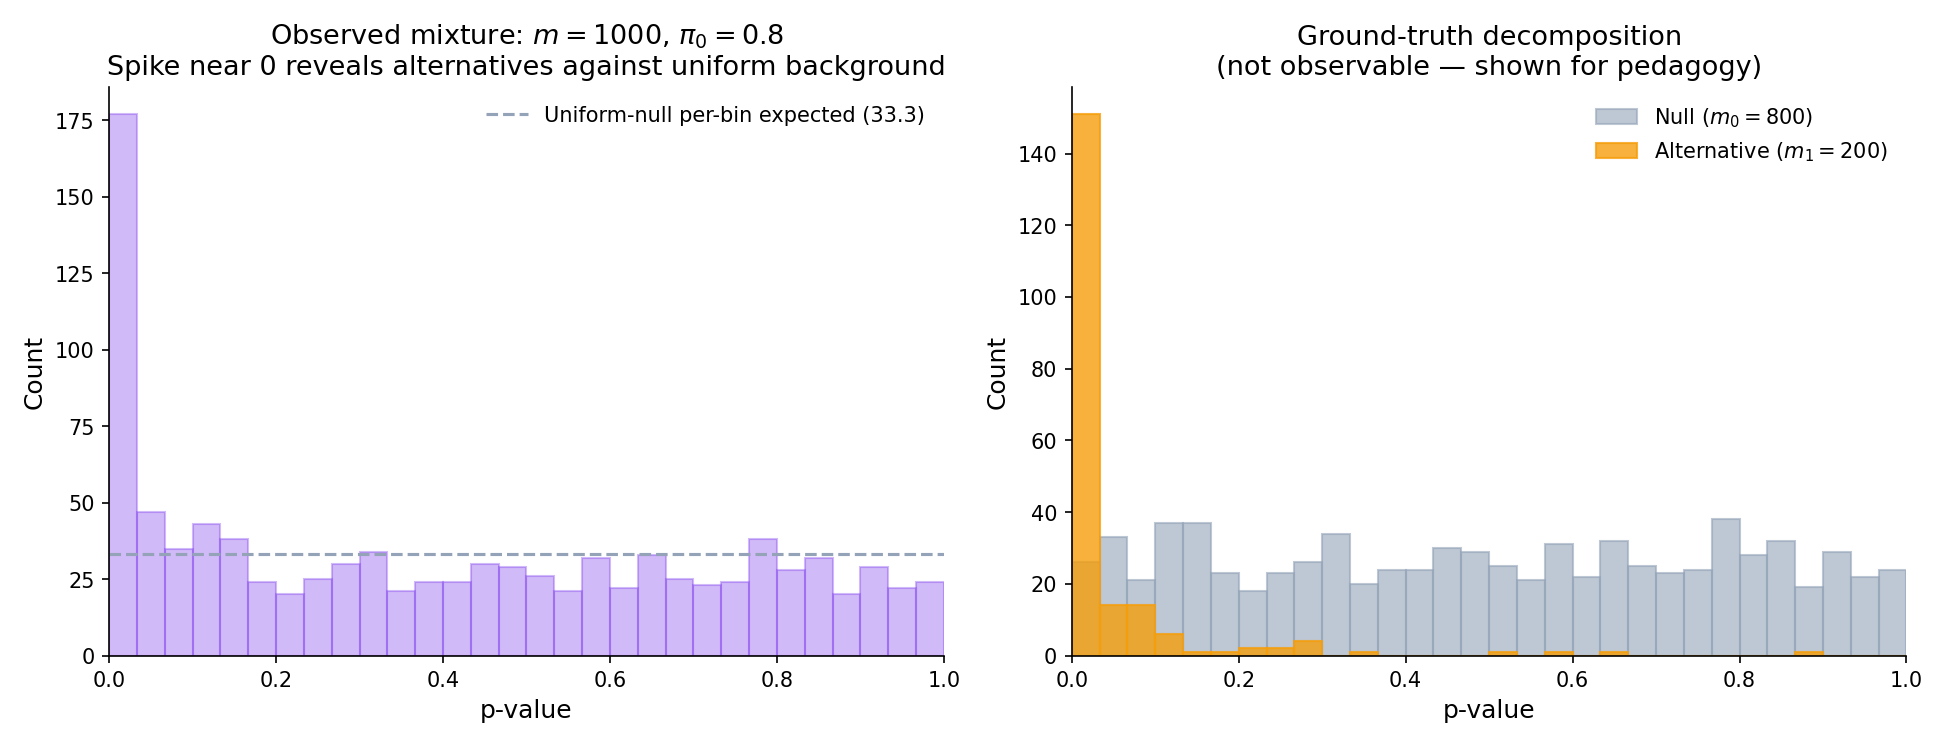

Saved 20-pvalue-mixture.png


In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Figure 3: p-value mixture distribution (§20.3)
# Under H0 p-values are uniform; under H1 they concentrate near zero.
# Shows what the statistician actually sees (left) vs the ground truth (right).
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED)
m, pi0 = 1000, 0.8
m0 = int(pi0 * m); m1 = m - m0
signal = 2.5

null_p = rng.uniform(0, 1, m0)
z_alt = rng.normal(signal, 1, m1)
alt_p = 1 - norm.cdf(z_alt)
pvals = np.concatenate([null_p, alt_p])

bins = np.linspace(0, 1, 31)
expected_null_per_bin = m / 30  # uniform null would put m/30 in each bin

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: observable mixture
ax1.hist(pvals, bins=bins, color=C['score'], alpha=0.35,
         edgecolor=C['score'], linewidth=1)
ax1.axhline(expected_null_per_bin, color=C['null'], lw=1.5, ls='--',
            label=f'Uniform-null per-bin expected ({expected_null_per_bin:.1f})')
ax1.set_xlabel('p-value')
ax1.set_ylabel('Count')
ax1.set_title(f'Observed mixture: $m = {m}$, $\\pi_0 = {pi0}$\n'
              'Spike near 0 reveals alternatives against uniform background')
ax1.legend(loc='upper right', frameon=False)
ax1.set_xlim(0, 1)

# Right: ground-truth decomposition (not observable in practice)
ax2.hist(null_p, bins=bins, color=C['null'], alpha=0.60,
         edgecolor=C['null'], linewidth=1, label=f'Null ($m_0 = {m0}$)')
ax2.hist(alt_p, bins=bins, color=C['alt'], alpha=0.80,
         edgecolor=C['alt'], linewidth=1, label=f'Alternative ($m_1 = {m1}$)')
ax2.set_xlabel('p-value')
ax2.set_ylabel('Count')
ax2.set_title('Ground-truth decomposition\n(not observable — shown for pedagogy)')
ax2.legend(loc='upper right', frameon=False)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-pvalue-mixture.png'))
plt.show()
print("Saved 20-pvalue-mixture.png")

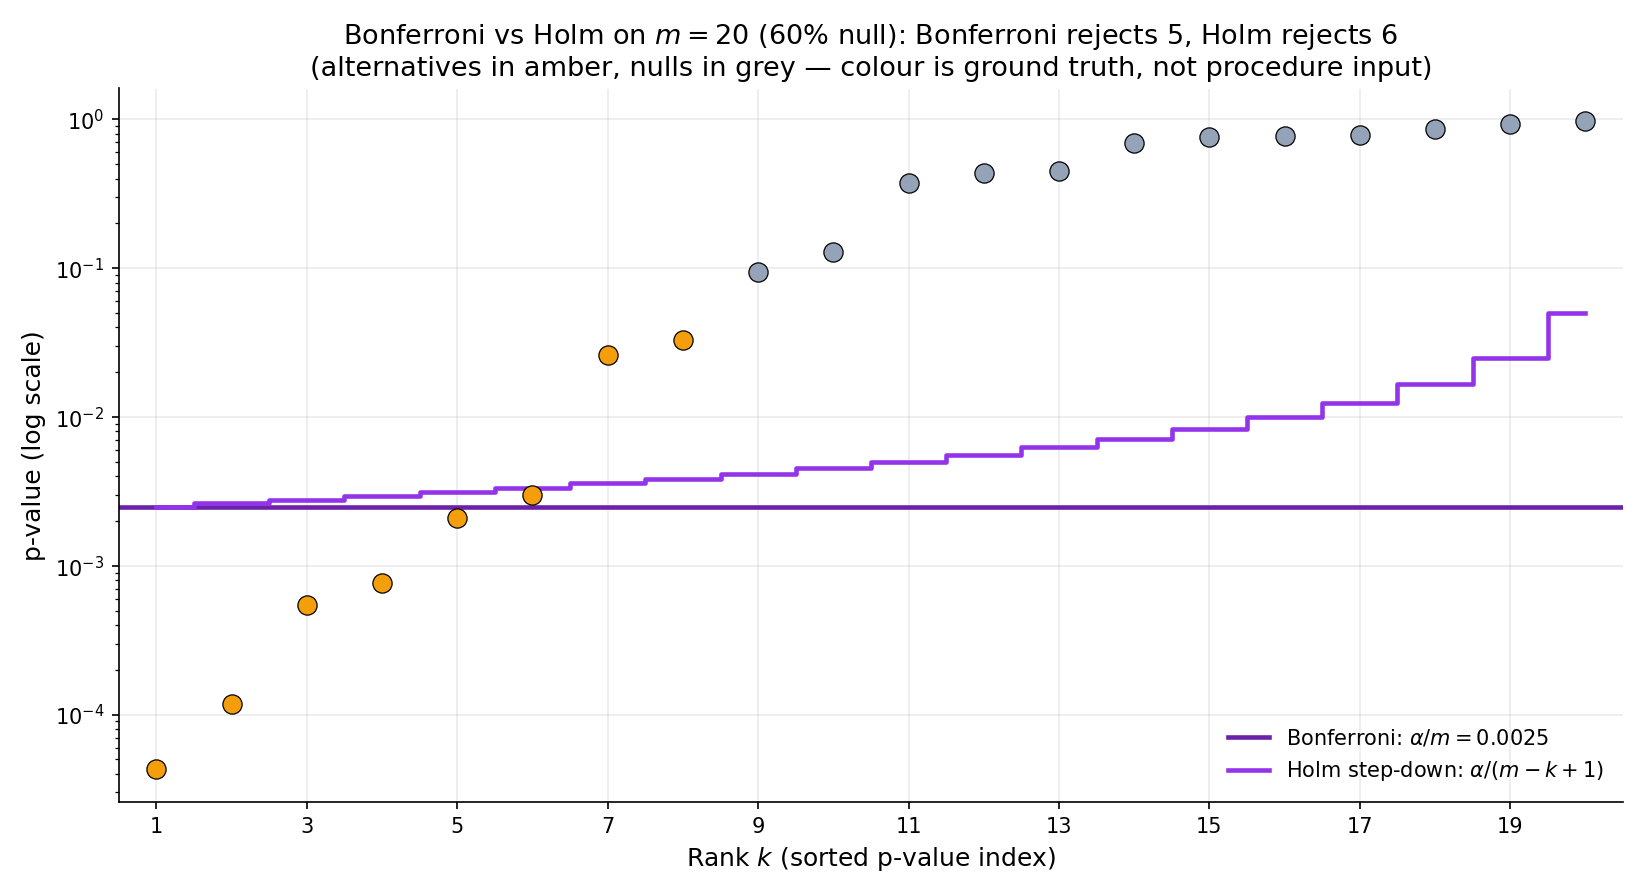

Saved 20-bonferroni-vs-holm.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Figure 4: Bonferroni vs Holm step-down (§20.5)
# Same sorted p-value vector with both thresholds overlaid.
# Holm's staircase rejects at least as much as Bonferroni's flat line.
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED)
m = 20
pi0 = 0.6
m0 = int(pi0 * m); m1 = m - m0

null_p = rng.uniform(0, 1, m0)
z_alt = rng.normal(2.8, 1, m1)
alt_p = 1 - norm.cdf(z_alt)
pvals = np.concatenate([null_p, alt_p])
is_null = np.concatenate([np.ones(m0, dtype=bool), np.zeros(m1, dtype=bool)])
order = np.argsort(pvals)
sorted_p = pvals[order]
sorted_null = is_null[order]

alpha = 0.05
ranks = np.arange(1, m + 1)
bonf_thresh = alpha / m
holm_thresh = alpha / (m - ranks + 1)

bonf_rej_count = bonferroni(pvals, alpha).sum()
holm_rej_count = holm(pvals, alpha).sum()

fig, ax = plt.subplots(figsize=(11, 6))

# Scatter sorted p-values, colored by ground-truth label (for pedagogy; not seen by procedure)
for i in range(m):
    color = C['alt'] if not sorted_null[i] else C['null']
    ax.scatter(ranks[i], sorted_p[i], s=85, color=color,
               edgecolor='black', linewidth=0.6, zorder=3)

# Bonferroni: flat line
ax.axhline(bonf_thresh, color=C['bonf'], lw=2.2,
           label=fr'Bonferroni: $\alpha/m = {bonf_thresh:.4f}$')
# Holm: step function alpha/(m - k + 1)
ax.step(ranks, holm_thresh, where='mid', color=C['holm'], lw=2.2,
        label=r'Holm step-down: $\alpha / (m - k + 1)$')

ax.set_yscale('log')
ax.set_xlabel(r'Rank $k$ (sorted p-value index)')
ax.set_ylabel('p-value (log scale)')
ax.set_title(f'Bonferroni vs Holm on $m = {m}$ (60% null): '
             f'Bonferroni rejects {bonf_rej_count}, Holm rejects {holm_rej_count}\n'
             '(alternatives in amber, nulls in grey — colour is ground truth, not procedure input)')
ax.legend(loc='lower right', frameon=False)
ax.set_xticks(np.arange(1, m + 1, 2))
ax.set_xlim(0.5, m + 0.5)
ax.grid(True, which='major', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-bonferroni-vs-holm.png'))
plt.show()
print("Saved 20-bonferroni-vs-holm.png")

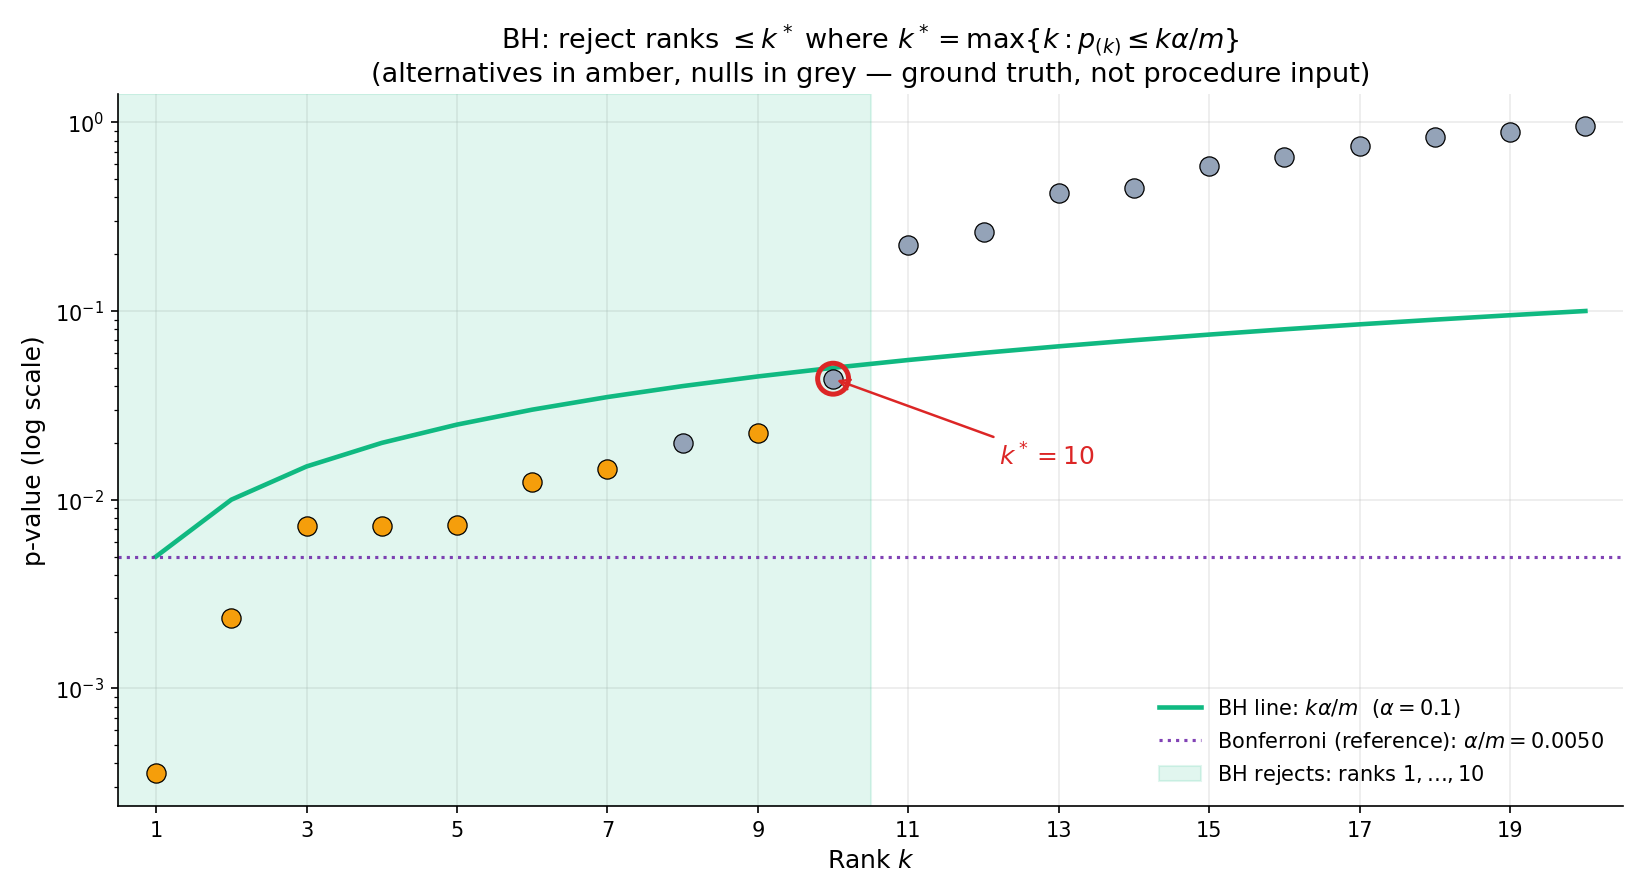

Saved 20-bh-algorithm.png  (k* = 10)


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Figure 5: Benjamini–Hochberg algorithm visualization (§20.7)
# The BH line k*alpha/m is diagonal. Largest k with p_(k) below line is k*.
# All hypotheses with rank <= k* are rejected.
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED + 1)
m = 20
pi0 = 0.6
m0 = int(pi0 * m); m1 = m - m0

null_p = rng.uniform(0, 1, m0)
z_alt = rng.normal(2.8, 1, m1)
alt_p = 1 - norm.cdf(z_alt)
pvals = np.concatenate([null_p, alt_p])
is_null = np.concatenate([np.ones(m0, dtype=bool), np.zeros(m1, dtype=bool)])
order = np.argsort(pvals)
sorted_p = pvals[order]
sorted_null = is_null[order]

alpha = 0.10
ranks = np.arange(1, m + 1)
bh_line = ranks * alpha / m

# Find k*: largest k with p_(k) <= k*alpha/m
k_star = 0
for k in range(m, 0, -1):
    if sorted_p[k-1] <= k * alpha / m:
        k_star = k
        break

fig, ax = plt.subplots(figsize=(11, 6))

# BH line and Bonferroni reference
ax.plot(ranks, bh_line, color=C['bh'], lw=2.2,
        label=fr'BH line: $k\alpha / m$  ($\alpha = {alpha}$)')
ax.axhline(alpha / m, color=C['bonf'], lw=1.5, ls=':', alpha=0.85,
           label=fr'Bonferroni (reference): $\alpha/m = {alpha/m:.4f}$')

# Shade the rejection region
if k_star > 0:
    ax.axvspan(0.5, k_star + 0.5, alpha=0.12, color=C['bh'],
               label=f'BH rejects: ranks $1, \\ldots, {k_star}$')

# Scatter p-values
for i in range(m):
    color = C['alt'] if not sorted_null[i] else C['null']
    ax.scatter(ranks[i], sorted_p[i], s=85, color=color,
               edgecolor='black', linewidth=0.6, zorder=3)

# Circle k*
if k_star > 0:
    ax.scatter([k_star], [sorted_p[k_star-1]], s=220,
               facecolors='none', edgecolor=C['warn'], linewidth=2.4, zorder=4)
    ax.annotate(f'$k^* = {k_star}$',
                xy=(k_star, sorted_p[k_star-1]),
                xytext=(k_star + 2.2, sorted_p[k_star-1] * 0.35),
                fontsize=12, color=C['warn'],
                arrowprops=dict(arrowstyle='->', color=C['warn'], lw=1.2))

ax.set_xlabel(r'Rank $k$')
ax.set_ylabel('p-value (log scale)')
ax.set_yscale('log')
ax.set_title(r'BH: reject ranks $\leq k^*$ where $k^* = \max\{k : p_{(k)} \leq k\alpha / m\}$'
             '\n(alternatives in amber, nulls in grey — ground truth, not procedure input)')
ax.legend(loc='lower right', frameon=False)
ax.set_xticks(np.arange(1, m + 1, 2))
ax.set_xlim(0.5, m + 0.5)
ax.grid(True, which='major', alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-bh-algorithm.png'))
plt.show()
print(f"Saved 20-bh-algorithm.png  (k* = {k_star})")

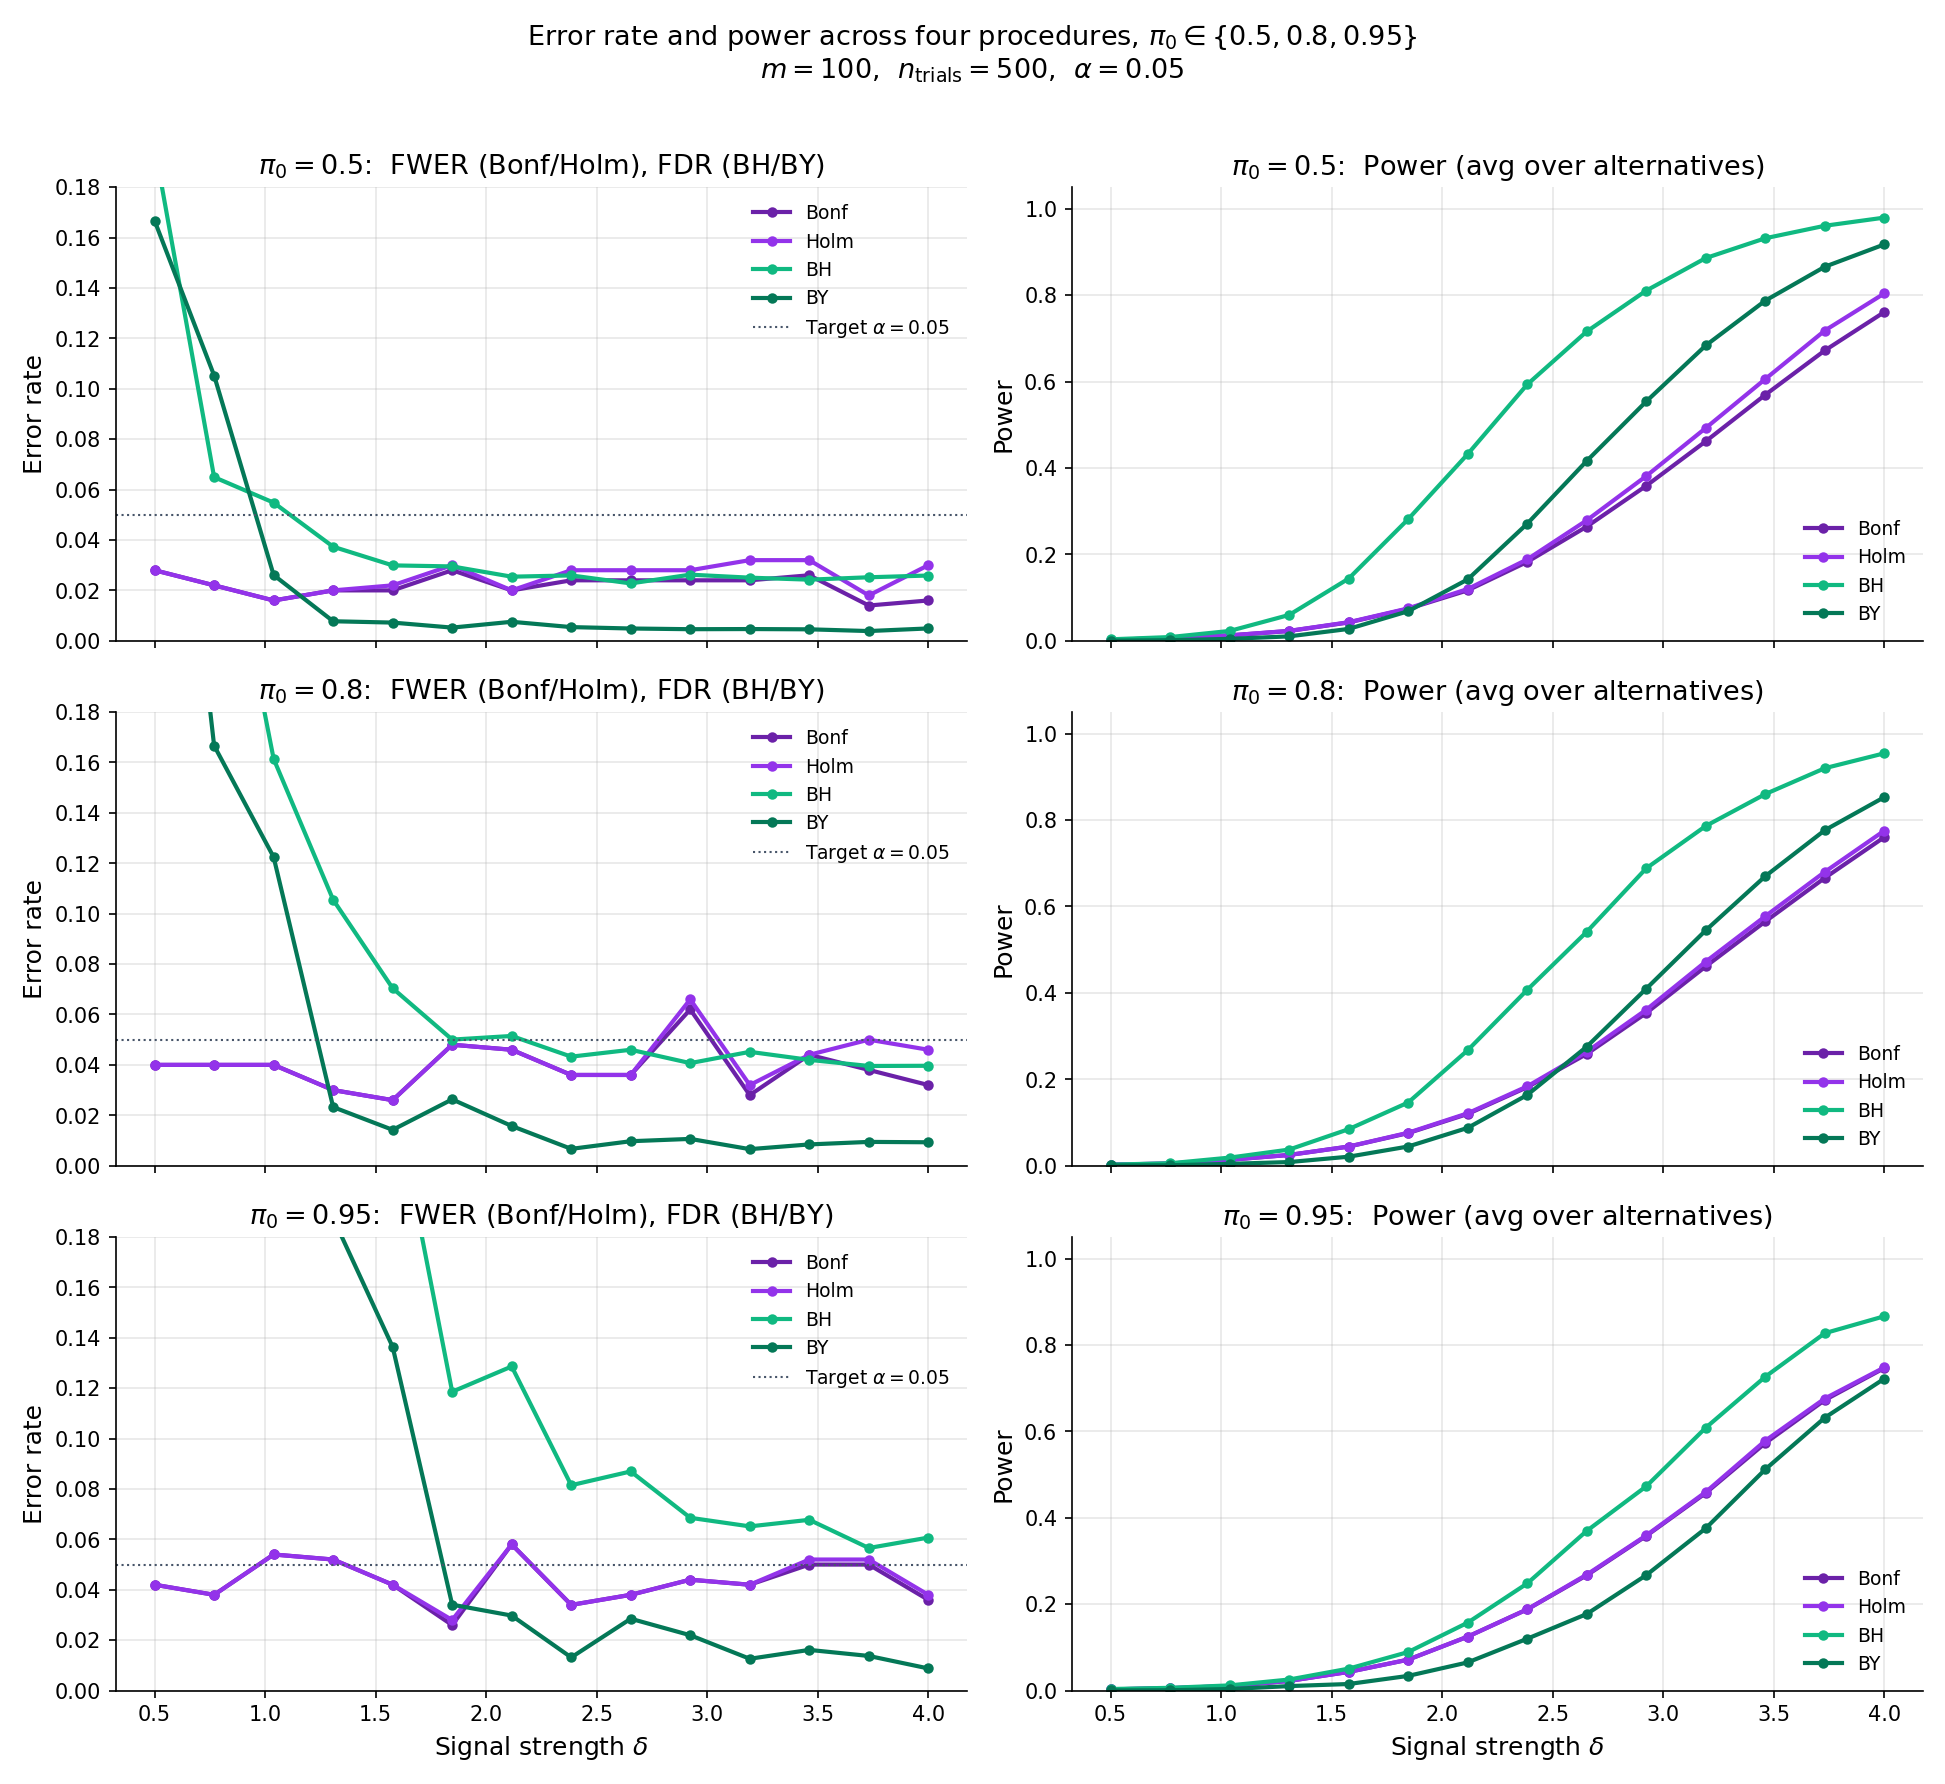

Saved 20-fdr-fwer-power.png


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Figure 6: FWER (Bonf/Holm) vs FDR (BH/BY), and power across pi_0 (§20.8)
# 3 rows × 2 cols.  Rows: pi_0 in {0.5, 0.8, 0.95}.
# Cols: error rate (FWER for FWER-procedures, FDR for FDR-procedures), power.
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED)
m = 100
alpha = 0.05
signal_grid = np.linspace(0.5, 4.0, 14)
n_trials = 500         # bump for lower Monte Carlo noise

procedures = [
    ('Bonf', C['bonf'], bonferroni, 'fwer'),
    ('Holm', C['holm'], holm,       'fwer'),
    ('BH',   C['bh'],   bh,         'fdr'),
    ('BY',   C['by'],   by,         'fdr'),
]

pi0_values = [0.5, 0.8, 0.95]
fig, axes = plt.subplots(3, 2, figsize=(13, 12), sharex=True)

for row, pi0 in enumerate(pi0_values):
    err_curves = {name: [] for name, *_ in procedures}
    pow_curves = {name: [] for name, *_ in procedures}

    for sig in signal_grid:
        agg = {name: {'V': 0, 'S': 0, 'R': 0, 'fwe_ct': 0, 'm1_sum': 0}
               for name, *_ in procedures}

        for _ in range(n_trials):
            p, is_null = simulate_pvalues(m, pi0, sig, rng)
            m1 = (~is_null).sum()
            for name, _, proc, _ in procedures:
                rej = proc(p, alpha)
                V = (rej & is_null).sum()
                S = (rej & ~is_null).sum()
                agg[name]['V'] += V
                agg[name]['S'] += S
                agg[name]['R'] += rej.sum()
                agg[name]['fwe_ct'] += int(V >= 1)
                agg[name]['m1_sum'] += m1

        for name, _, _, kind in procedures:
            if kind == 'fwer':
                err = agg[name]['fwe_ct'] / n_trials
            else:
                err = agg[name]['V'] / max(agg[name]['R'], 1)
            power = agg[name]['S'] / max(agg[name]['m1_sum'], 1)
            err_curves[name].append(err)
            pow_curves[name].append(power)

    ax_e, ax_p = axes[row, 0], axes[row, 1]

    for name, color, _, _ in procedures:
        ax_e.plot(signal_grid, err_curves[name], color=color, lw=2, marker='o', ms=4, label=name)
    ax_e.axhline(alpha, color=C['ref'], lw=1, ls=':', label=fr'Target $\alpha = {alpha}$')
    ax_e.set_title(fr'$\pi_0 = {pi0}$:  FWER (Bonf/Holm), FDR (BH/BY)')
    ax_e.set_ylabel('Error rate')
    ax_e.set_ylim(0, max(3 * alpha, 0.18))
    ax_e.legend(loc='upper right', frameon=False, fontsize=9)
    ax_e.grid(True, alpha=0.3)

    for name, color, _, _ in procedures:
        ax_p.plot(signal_grid, pow_curves[name], color=color, lw=2, marker='o', ms=4, label=name)
    ax_p.set_title(fr'$\pi_0 = {pi0}$:  Power (avg over alternatives)')
    ax_p.set_ylabel('Power')
    ax_p.set_ylim(0, 1.05)
    ax_p.legend(loc='lower right', frameon=False, fontsize=9)
    ax_p.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel(r'Signal strength $\delta$')
axes[-1, 1].set_xlabel(r'Signal strength $\delta$')

fig.suptitle(f'Error rate and power across four procedures, $\\pi_0 \\in \\{{0.5, 0.8, 0.95\\}}$\n'
             f'$m = {m}$,  $n_{{\\rm trials}} = {n_trials}$,  $\\alpha = {alpha}$',
             fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(os.path.join(OUTPUT_DIR, '20-fdr-fwer-power.png'))
plt.show()
print("Saved 20-fdr-fwer-power.png")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Figure 7: Realistic-scale demonstration m=20,000 (§20.8)
# GWAS-like setting: 20K hypotheses, 200 true alternatives (pi_0 = 0.99).
# Shows Bonferroni's near-zero power vs BH's power retention with FDR control.
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED)
m = 20_000
pi0 = 0.99                    # 200 true alternatives
signal = 3.5                  # moderate-strong effect
alpha = 0.05

pvals, is_null = simulate_pvalues(m, pi0, signal, rng)
m1 = (~is_null).sum()

procs = [
    ('Bonf', C['bonf'], bonferroni),
    ('Holm', C['holm'], holm),
    ('BH',   C['bh'],   bh),
    ('BY',   C['by'],   by),
]

results = {}
for name, color, proc in procs:
    rej = proc(pvals, alpha)
    V = (rej & is_null).sum()
    S = (rej & ~is_null).sum()
    R = rej.sum()
    results[name] = {
        'color': color, 'R': R, 'V': V, 'S': S,
        'power': S / max(m1, 1),
        'fdp': V / max(R, 1),
    }

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: per-procedure S and V (true/false discoveries)
names = [n for n, *_ in procs]
colors = [results[n]['color'] for n in names]
S_vals = [results[n]['S'] for n in names]
V_vals = [results[n]['V'] for n in names]

x = np.arange(len(names))
w = 0.35
ax1.bar(x - w/2, S_vals, w,
        color=colors, alpha=0.9, edgecolor='black', lw=0.5,
        label=f'True discoveries  (of $m_1 = {m1}$)')
ax1.bar(x + w/2, V_vals, w,
        color=colors, alpha=0.35, edgecolor='black', lw=0.5,
        hatch='///', label='False discoveries')
ax1.set_xticks(x); ax1.set_xticklabels(names)
ax1.set_ylabel('Count')
ax1.set_title(f'Detections on $m = {m:,}$ tests, one replicate\n'
              f'$\\pi_0 = {pi0}$, effect size $\\delta = {signal}$, $\\alpha = {alpha}$')
ax1.legend(loc='upper left', frameon=False)
ax1.grid(True, axis='y', alpha=0.3)

# Right: realized power vs realized FDP (single replicate)
for name, data in results.items():
    ax2.scatter(data['fdp'], data['power'], s=220,
                color=data['color'], edgecolor='black', lw=1, zorder=3)
    ax2.annotate(name, (data['fdp'], data['power']),
                 xytext=(10, 6), textcoords='offset points',
                 fontsize=11, fontweight='bold', color=data['color'])
ax2.axvline(alpha, color=C['ref'], ls=':', lw=1.5, label=fr'FDR target $\alpha = {alpha}$')
ax2.set_xlabel('Realized false-discovery proportion (V / R)')
ax2.set_ylabel('Power (S / $m_1$)')
ax2.set_title('Power-vs-FDP tradeoff on this replicate\n(BH/BY sacrifice a small FDP for large power gains)')
ax2.set_xlim(-0.005, max(0.15, max(r['fdp'] for r in results.values()) * 1.25))
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right', frameon=False)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-genomics-simulation.png'))
plt.show()
print(f"Saved 20-genomics-simulation.png")
for name, r in results.items():
    print(f"  {name}: R={r['R']:4d}  V={r['V']:3d}  S={r['S']:3d}  "
          f"power={r['power']:.3f}  FDP={r['fdp']:.4f}")

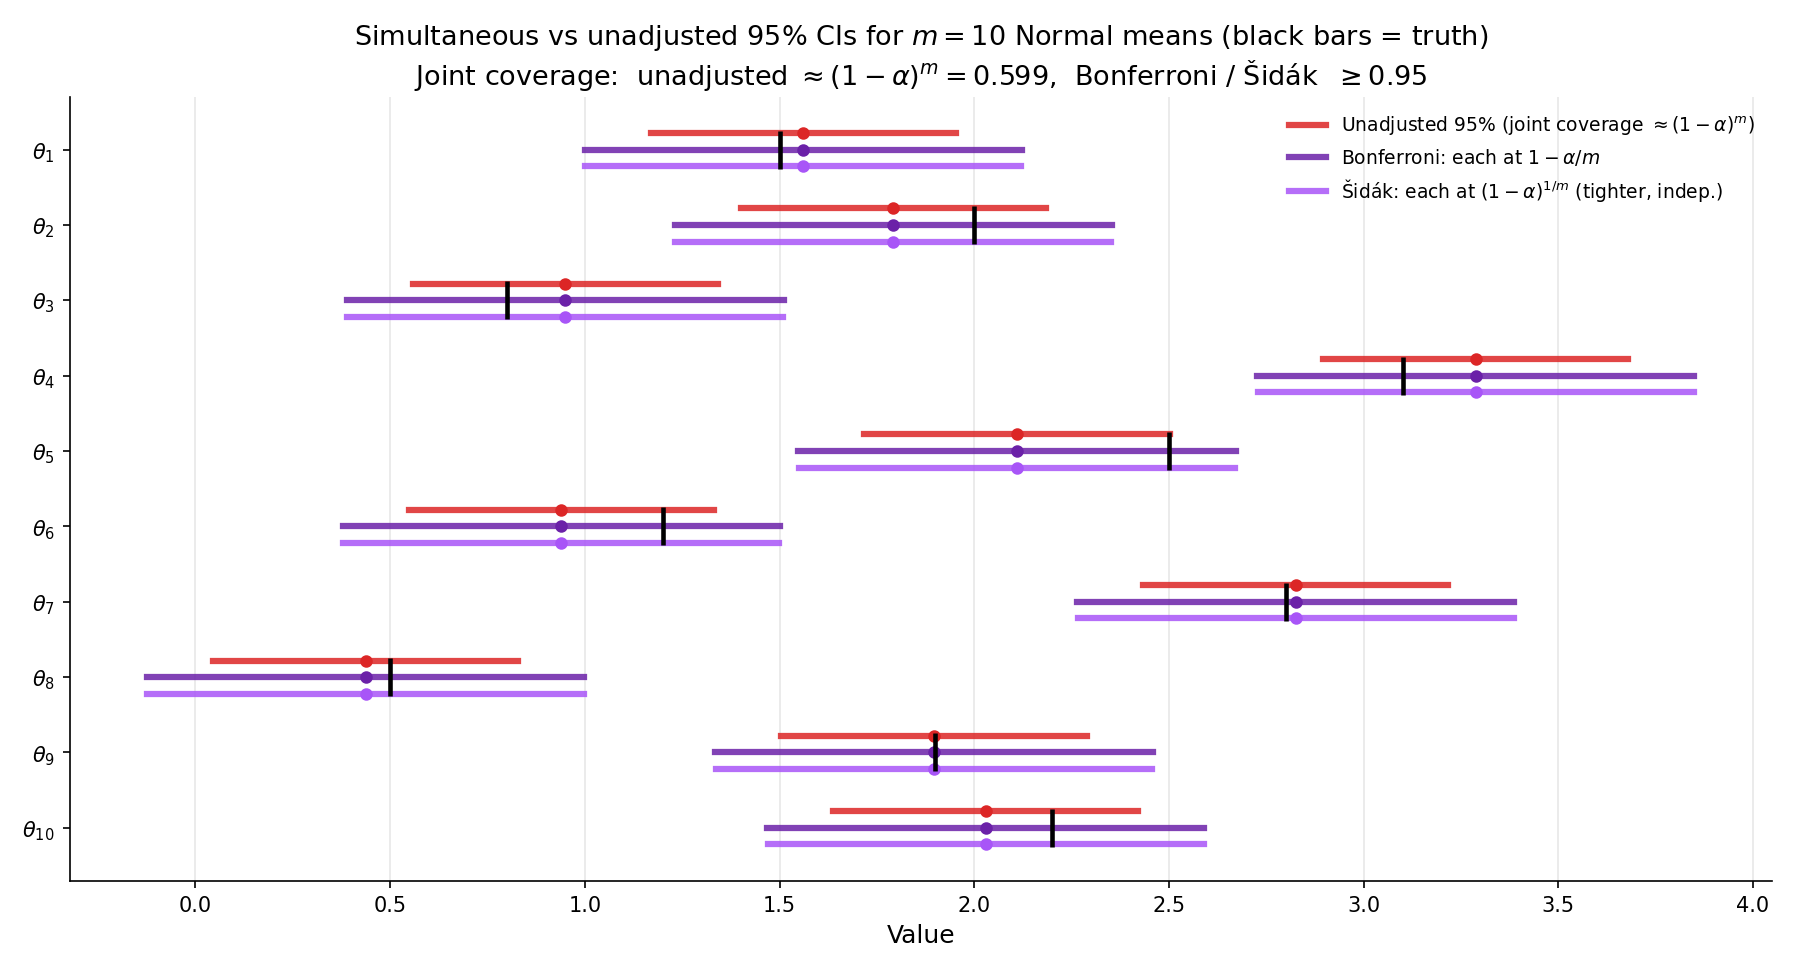

Saved 20-simultaneous-cis.png
  Unadjusted half-width: 0.3920
  Bonferroni half-width: 0.5614  (ratio 1.432)
  Šidák half-width:      0.5599  (tighter than Bonferroni under indep.)


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Figure 8: Simultaneous CIs via Bonferroni and Šidák (§20.9)
# Ten independent Normal means. Individual 95% CIs have joint coverage (1-alpha)^m ≈ 0.60.
# Bonferroni and Šidák corrections restore joint coverage ≥ 1 - alpha.
# ═══════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(SEED)
m = 10
alpha = 0.05
n = 25
sigma = 1.0
true_theta = np.array([1.5, 2.0, 0.8, 3.1, 2.5, 1.2, 2.8, 0.5, 1.9, 2.2])
se = sigma / np.sqrt(n)

xbars = rng.normal(true_theta, se)

z_ind   = norm.ppf(1 - alpha/2)
z_bonf  = norm.ppf(1 - alpha / (2*m))
# Šidák: per-interval alpha' = 1 - (1-alpha)^(1/m)
alpha_sidak = 1 - (1 - alpha)**(1/m)
z_sidak = norm.ppf(1 - alpha_sidak / 2)

def ci(center, z):
    return center - z*se, center + z*se

ind_lo,   ind_hi   = ci(xbars, z_ind)
bonf_lo,  bonf_hi  = ci(xbars, z_bonf)
sidak_lo, sidak_hi = ci(xbars, z_sidak)

fig, ax = plt.subplots(figsize=(12, 6.5))
y = np.arange(m)
dy = 0.22

for i in range(m):
    # Unadjusted 95%
    ax.plot([ind_lo[i], ind_hi[i]], [y[i] - dy]*2,
            color=C['warn'], lw=3, alpha=0.85,
            label='Unadjusted 95% (joint coverage $\\approx (1-\\alpha)^m$)' if i == 0 else None)
    ax.plot(xbars[i], y[i] - dy, 'o', color=C['warn'], ms=5)
    # Bonferroni
    ax.plot([bonf_lo[i], bonf_hi[i]], [y[i]]*2,
            color=C['bonf'], lw=3, alpha=0.85,
            label=f'Bonferroni: each at $1 - \\alpha/m$' if i == 0 else None)
    ax.plot(xbars[i], y[i], 'o', color=C['bonf'], ms=5)
    # Šidák
    ax.plot([sidak_lo[i], sidak_hi[i]], [y[i] + dy]*2,
            color=C['sidak'], lw=3, alpha=0.85,
            label=f'Šidák: each at $(1-\\alpha)^{{1/m}}$ (tighter, indep.)' if i == 0 else None)
    ax.plot(xbars[i], y[i] + dy, 'o', color=C['sidak'], ms=5)
    # True value
    ax.plot(true_theta[i], y[i], marker='|', color='black', ms=18, mew=2.2)

ax.set_yticks(y)
ax.set_yticklabels([fr'$\theta_{{{i+1}}}$' for i in range(m)])
ax.set_xlabel('Value')

joint_unadj = (1 - alpha)**m
title = (f'Simultaneous vs unadjusted 95% CIs for $m = {m}$ Normal means (black bars = truth)\n'
         f'Joint coverage:  unadjusted $\\approx (1-\\alpha)^m = {joint_unadj:.3f}$,  '
         f'Bonferroni / Šidák  $\\geq {1-alpha:.2f}$')
ax.set_title(title)
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.grid(True, axis='x', alpha=0.3)
ax.set_ylim(-0.7, m - 0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-simultaneous-cis.png'))
plt.show()
print("Saved 20-simultaneous-cis.png")
print(f"  Unadjusted half-width: {z_ind*se:.4f}")
print(f"  Bonferroni half-width: {z_bonf*se:.4f}  (ratio {z_bonf/z_ind:.3f})")
print(f"  Šidák half-width:      {z_sidak*se:.4f}  (tighter than Bonferroni under indep.)")

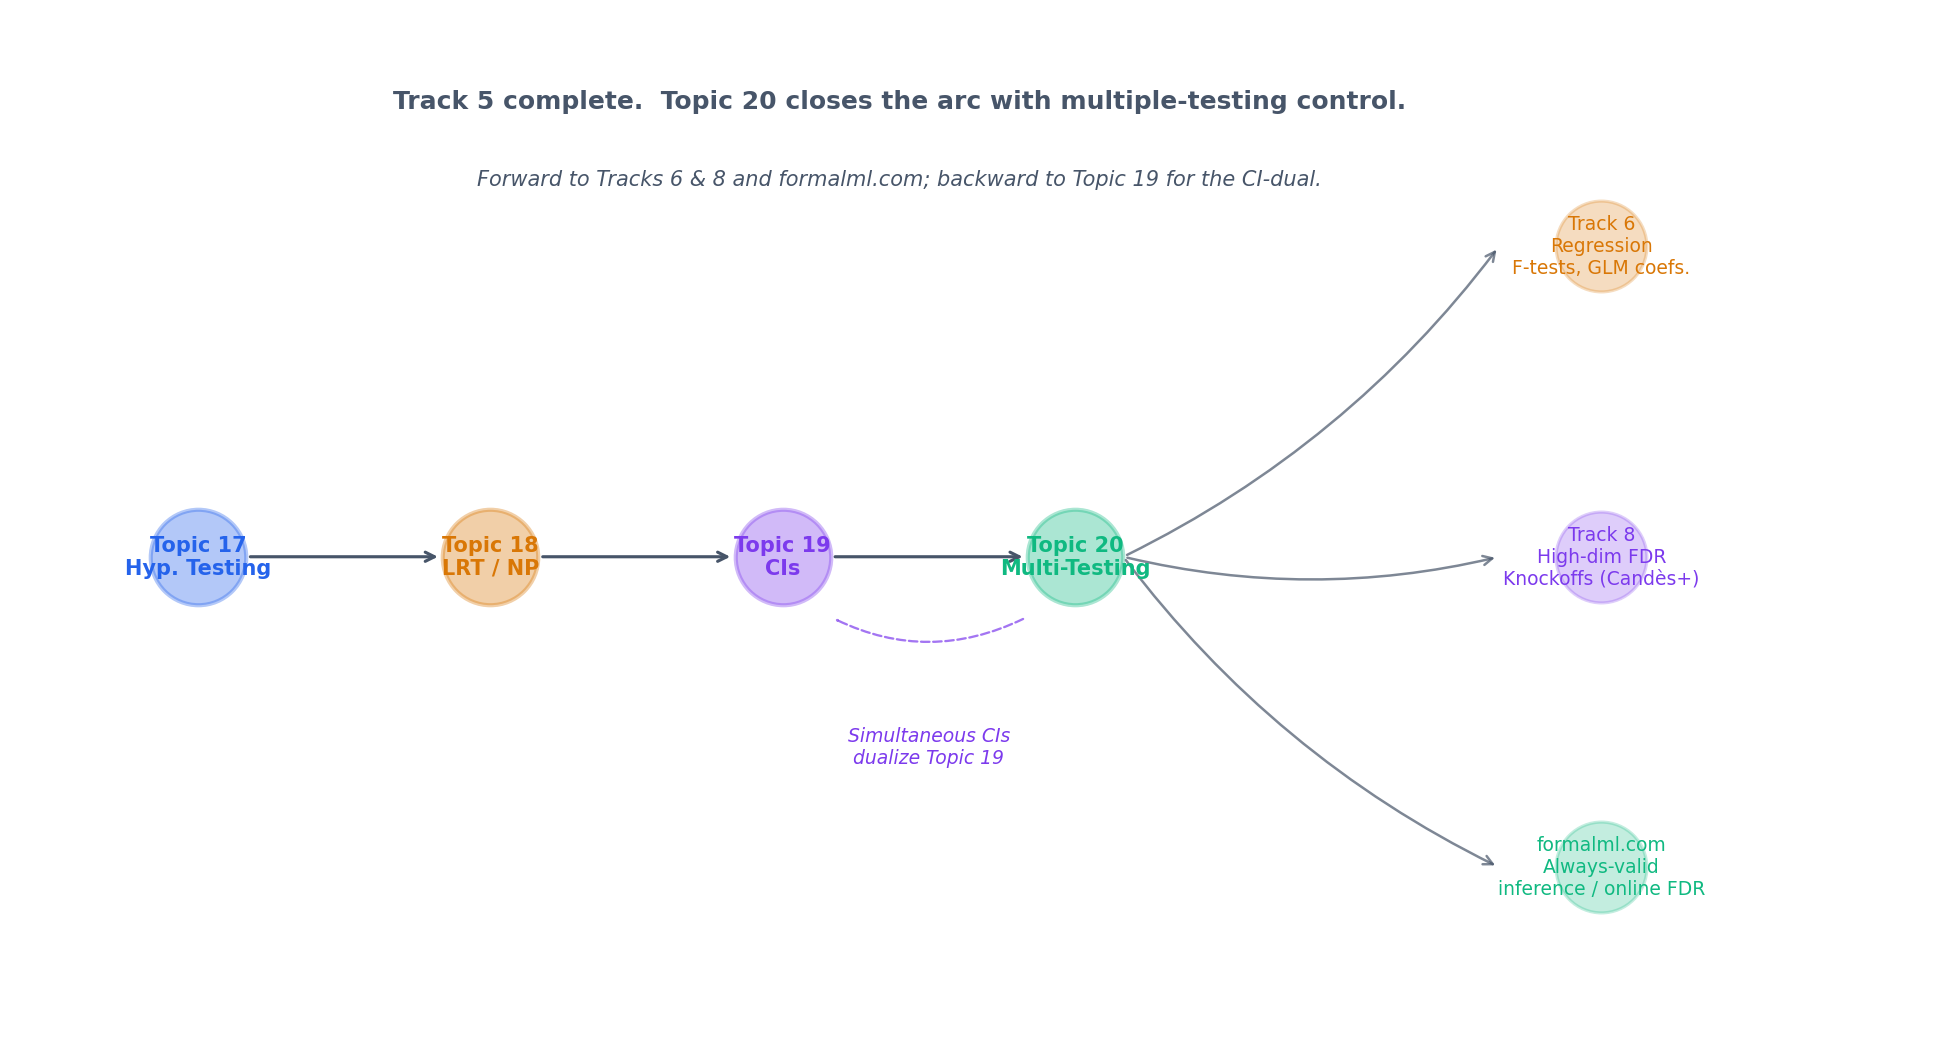

Saved 20-forward-map.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Figure 9: Track 5 close + forward pointers (§20.10)
# Topic 20 sits at the end of Track 5, with outgoing edges to Track 6 / Track 8 /
# formalml.com.  Backward edge to Topic 19 for the CI-dual relationship.
# ═══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(13, 7))

spine_y = 4.0
spine_x = [1.2, 3.2, 5.2, 7.2]
spine_labels = ['Topic 17\nHyp. Testing', 'Topic 18\nLRT / NP', 'Topic 19\nCIs', 'Topic 20\nMulti-Testing']
spine_colors = [C['pivot'], C['wald'], C['score'], C['bh']]

# Track 5 spine
for x, label, color in zip(spine_x, spine_labels, spine_colors):
    ax.scatter([x], [spine_y], s=2100, color=color, alpha=0.35, edgecolor=color, lw=2, zorder=3)
    ax.annotate(label, (x, spine_y), ha='center', va='center',
                fontsize=10, fontweight='bold', color=color, zorder=4)

for i in range(len(spine_x) - 1):
    ax.annotate('', xy=(spine_x[i+1] - 0.33, spine_y), xytext=(spine_x[i] + 0.33, spine_y),
                arrowprops=dict(arrowstyle='->', color=C['ref'], lw=1.5))

# Curved back-arrow from Topic 20 to Topic 19 (CI dual)
arrow = FancyArrowPatch((spine_x[3] - 0.33, spine_y - 0.35),
                        (spine_x[2] + 0.33, spine_y - 0.35),
                        arrowstyle='->', color=C['score'], lw=1.1, alpha=0.7,
                        linestyle='--', connectionstyle='arc3,rad=-0.25')
ax.add_patch(arrow)
ax.text((spine_x[2] + spine_x[3])/2, spine_y - 1.1,
        'Simultaneous CIs\ndualize Topic 19',
        ha='center', va='center', fontsize=9, color=C['score'], style='italic')

# Forward nodes (Topic 20 outgoing)
center = (spine_x[3], spine_y)
forward = [
    ('Track 6\nRegression\nF-tests, GLM coefs.',  (10.8, 5.8), C['wald']),
    ('Track 8\nHigh-dim FDR\nKnockoffs (Candès+)', (10.8, 4.0), C['score']),
    ('formalml.com\nAlways-valid\ninference / online FDR', (10.8, 2.2), C['lrt']),
]

for label, (fx, fy), color in forward:
    ax.scatter([fx], [fy], s=1900, color=color, alpha=0.25, edgecolor=color, lw=1.5, zorder=3)
    ax.annotate(label, (fx, fy), ha='center', va='center',
                fontsize=9, color=color, zorder=4)
    ax.annotate('', xy=(fx - 0.7, fy), xytext=(center[0] + 0.33, center[1]),
                arrowprops=dict(arrowstyle='->', color=C['ref'], lw=1.2,
                                alpha=0.7, connectionstyle='arc3,rad=0.12'))

ax.text(6.0, 6.6, 'Track 5 complete.  Topic 20 closes the arc with multiple-testing control.',
        ha='center', fontsize=12, fontweight='bold', color=C['ref'])
ax.text(6.0, 6.15, 'Forward to Tracks 6 & 8 and formalml.com; backward to Topic 19 for the CI-dual.',
        ha='center', fontsize=10, color=C['ref'], style='italic')

ax.set_xlim(0, 13)
ax.set_ylim(1.3, 7.1)
ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20-forward-map.png'))
plt.show()
print("Saved 20-forward-map.png")

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Verification helper (brief §6.2 test-harness values)
# Computes the exact expected values encoded as regression tests in testing.ts.
# Run this cell whenever the procedures are modified to verify invariants hold.
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 72)
print("  BRIEF §6.2 TEST-HARNESS VALUES  (match these in src/lib/stat/testing.ts)")
print("=" * 72)

# ─── Test T1: BH cutoff on a fixed sorted vector ─────────────────────────────
print("\n[T1] BH cutoff on a known sorted p-value vector")
p_T1 = np.array([0.0005, 0.003, 0.011, 0.021, 0.043,
                 0.051, 0.087, 0.21, 0.33, 0.55])
alpha_T1 = 0.05
m_T1 = len(p_T1)
print(f"    Input:  p = {p_T1.tolist()}")
print(f"    Config: m = {m_T1}, alpha = {alpha_T1}")
print(f"    Threshold grid k*alpha/m:")
for k in range(1, m_T1 + 1):
    t = k * alpha_T1 / m_T1
    mark = 'PASS' if p_T1[k-1] <= t else 'FAIL'
    print(f"      k={k:2d}:  p_(k)={p_T1[k-1]:.4f}   threshold={t:.4f}   [{mark}]")
rej_T1 = bh(p_T1, alpha_T1)
k_star_T1 = rej_T1.sum()
print(f"    ---> EXPECTED: k* = {k_star_T1}, reject ranks 1..{k_star_T1}")

# ─── Test T2: Holm ≡ Bonferroni when single rejection ────────────────────────
print("\n[T2] Holm equivalent to Bonferroni when only one rejection occurs")
p_T2 = np.array([0.0001, 0.08, 0.12, 0.5])
b_T2 = bonferroni(p_T2, 0.05)
h_T2 = holm(p_T2, 0.05)
print(f"    Input:       p = {p_T2.tolist()}")
print(f"    Bonferroni rejects: {b_T2.tolist()}")
print(f"    Holm       rejects: {h_T2.tolist()}")
print(f"    ---> EXPECTED: identical boolean vectors; match = {np.array_equal(b_T2, h_T2)}")

# ─── Test T3: BH FDR Monte Carlo control ─────────────────────────────────────
print("\n[T3] BH FDR Monte Carlo: empirical FDR <= alpha * pi_0 (up to MC error)")
print("     Config: m=200, pi_0=0.8, delta=3.0, alpha=0.05, 3000 trials")
rng_T3 = np.random.default_rng(123)
n_trials_T3 = 3000
V_sum = R_sum = fwer_ct = 0
pow_sum = 0.0
for _ in range(n_trials_T3):
    p, is_null = simulate_pvalues(200, 0.8, 3.0, rng_T3)
    m1 = (~is_null).sum()
    rej = bh(p, 0.05)
    V = (rej & is_null).sum()
    S = (rej & ~is_null).sum()
    V_sum += V; R_sum += rej.sum()
    fwer_ct += int(V >= 1)
    if m1: pow_sum += S / m1
fdr_est = V_sum / max(R_sum, 1)
fwer_est = fwer_ct / n_trials_T3
pow_est = pow_sum / n_trials_T3
print(f"    Empirical FDR(BH)   = {fdr_est:.4f}")
print(f"    Theoretical bound   = alpha * pi_0 = 0.0400")
print(f"    Empirical FWER(BH)  = {fwer_est:.4f}   (BH does NOT control FWER)")
print(f"    Empirical avg power = {pow_est:.4f}")
print(f"    ---> EXPECTED: FDR in [0.030, 0.050]; FWER large (> 0.50) — BH controls FDR, not FWER")

# ─── Test T4: FWER explosion table ───────────────────────────────────────────
print("\n[T4] FWER explosion table at alpha = 0.05")
print("      m         1-(1-alpha)^m       union bound")
for m_val in [1, 5, 10, 20, 50, 100, 1000]:
    naive = 1 - (1 - 0.05) ** m_val
    union = min(m_val * 0.05, 1.0)
    print(f"     {m_val:5d}      {naive:9.4f}           {union:9.4f}")
print("    ---> EXPECTED: at m=20, FWER = 0.6415; at m=100, FWER = 0.9941")

# ─── Test T5: Harmonic number for BY normalization ───────────────────────────
print("\n[T5] Benjamini-Yekutieli harmonic-number normalization c_m = sum_{k=1}^m 1/k")
for m_val in [10, 100, 1000, 20000]:
    c = np.sum(1.0 / np.arange(1, m_val + 1))
    print(f"    m = {m_val:5d}:  c_m = {c:.4f}")
print("    ---> EXPECTED: c_10 = 2.9290, c_100 = 5.1874, c_1000 = 7.4855")

print("\n" + "=" * 72)
print("  All verification values computed.")
print("=" * 72)

  BRIEF §6.2 TEST-HARNESS VALUES  (match these in src/lib/stat/testing.ts)

[T1] BH cutoff on a known sorted p-value vector
    Input:  p = [0.0005, 0.003, 0.011, 0.021, 0.043, 0.051, 0.087, 0.21, 0.33, 0.55]
    Config: m = 10, alpha = 0.05
    Threshold grid k*alpha/m:
      k= 1:  p_(k)=0.0005   threshold=0.0050   [PASS]
      k= 2:  p_(k)=0.0030   threshold=0.0100   [PASS]
      k= 3:  p_(k)=0.0110   threshold=0.0150   [PASS]
      k= 4:  p_(k)=0.0210   threshold=0.0200   [FAIL]
      k= 5:  p_(k)=0.0430   threshold=0.0250   [FAIL]
      k= 6:  p_(k)=0.0510   threshold=0.0300   [FAIL]
      k= 7:  p_(k)=0.0870   threshold=0.0350   [FAIL]
      k= 8:  p_(k)=0.2100   threshold=0.0400   [FAIL]
      k= 9:  p_(k)=0.3300   threshold=0.0450   [FAIL]
      k=10:  p_(k)=0.5500   threshold=0.0500   [FAIL]
    ---> EXPECTED: k* = 3, reject ranks 1..3

[T2] Holm equivalent to Bonferroni when only one rejection occurs
    Input:       p = [0.0001, 0.08, 0.12, 0.5]
    Bonferroni rejects: [True

## Summary

**Nine figures saved** to `public/images/topics/multiple-testing-and-false-discovery/`:

1. `20-fwer-explosion.png` — the motivating picture (§20.1)
2. `20-closed-testing-tree.png` — closed-testing principle on $m=3$ (§20.2)
3. `20-pvalue-mixture.png` — null-uniform + alternative-driven mass near 0 (§20.3)
4. `20-bonferroni-vs-holm.png` — FWER step-down (§20.5)
5. `20-bh-algorithm.png` — BH rank-ordered threshold with $k^*$ circled (§20.7)
6. `20-fdr-fwer-power.png` — 3×2 grid across $\pi_0 \in \{0.5, 0.8, 0.95\}$ (§20.8)
7. `20-genomics-simulation.png` — $m = 20{,}000$ realistic-scale (§20.8)
8. `20-simultaneous-cis.png` — unadjusted vs Bonferroni vs Šidák bands (§20.9)
9. `20-forward-map.png` — Track 5 close with forward / backward pointers (§20.10)

**Test-harness values** (Cell 12 output) consumed by `src/lib/stat/testing.ts`:

| Test | Expected |
|---|---|
| BH $k^*$ on the 10-vector at $\alpha = 0.05$ | $k^* = 3$ |
| Holm $\equiv$ Bonferroni on single-rejection case | boolean match |
| BH empirical FDR at $(m=200, \pi_0=0.8, \delta=3.0)$ | $\in [0.030, 0.050]$ |
| FWER at $m=20$, $\alpha=0.05$ | $0.6415$ |
| FWER at $m=100$, $\alpha=0.05$ | $0.9941$ |
| Harmonic $c_{10}$ (BY normalization) | $2.9290$ |
| Harmonic $c_{100}$ | $5.1874$ |
| Harmonic $c_{1000}$ | $7.4855$ |

**Seed** = 42. Each figure cell re-seeds a local `Generator` where sampling occurs so figures reproduce in isolation.

**Procedures implemented** in Cell 2 (reused throughout):
- `bonferroni(pvals, alpha)` — single-step FWER
- `holm(pvals, alpha)` — step-down FWER
- `sidak(pvals, alpha)` — single-step FWER under independence
- `hochberg(pvals, alpha)` — step-up FWER under independence
- `bh(pvals, alpha)` — Benjamini–Hochberg step-up FDR
- `by(pvals, alpha)` — BH at $\alpha / H_m$ under arbitrary dependence
- `storey_bh(pvals, alpha, lam)` — adaptive BH with $\pi_0$ estimation

These mirror (and will be ported verbatim into) `src/lib/stat/testing.ts`.
